# LLM-Driven Ontology Generation: Pipeline Demonstration

This notebook demonstrates the complete **Top-Down Skeleton + Bottom-Up Population** algorithm for generating RDF ontologies from a domain using LLMs.

We'll walk through all 4 phases:
1. **Structured Seed** — Generate a multi-level taxonomic skeleton
2. **Structural Validation** — Validate and prune the seed structure
3. **UCB1 Expansion** — Iteratively expand the ontology using a multi-armed bandit
4. **RDF Serialization** — Emit hierarchical RDF triples and visualize

## Setup

Configure the LLM client and ontology parameters.

In [2]:
import json
import os
from ontogen import ChatGpt, Ontology, OntologyLevel, DEFAULT_LEVEL_SCHEMA

# Configuration
DOMAIN = "Star Trek"  # Change this to explore other domains
API_KEY = os.getenv("OPENAI_API_KEY", "")
MODEL = "gpt-4o-mini"
SEED_SIZE = 3  # Number of top-level classes to seed
MAX_ITERATIONS = 200  # Max expansion iterations
EXPLORATION_CONSTANT = 1.42  # UCB1 exploration parameter
SIMILARITY_THRESHOLD = 70  # Minimum similarity (0-100) to accept relationships

print(f"Domain: {DOMAIN}")
print(f"API Key configured: {bool(API_KEY)}")
print(f"Default level schema: {[level.name for level in DEFAULT_LEVEL_SCHEMA]}")

Domain: Star Trek
API Key configured: True
Default level schema: ['class', 'subclass', 'instance']


In [3]:
# Initialize LLM client and ontology
agent = ChatGpt(api_key=API_KEY, model=MODEL)

ontology = Ontology(
    domain=DOMAIN,
    agent=agent,
    level_schema=DEFAULT_LEVEL_SCHEMA,
    exploration_constant=EXPLORATION_CONSTANT,
    max_iterations=MAX_ITERATIONS,
    similarity_threshold=SIMILARITY_THRESHOLD,
    max_workers = 15,
    class_discovery_interval=10
)

print(f"Ontology initialized for domain: {ontology.domain}")

Ontology initialized for domain: Star Trek


## Ontology generation

Iteratively expand the ontology using a multi-armed bandit (UCB1) strategy.
For each iteration, we select the most promising expandable node and generate new candidates.

Running full pipeline with max_iterations=200...
Similarity threshold: 70
Exploration constant (UCB1): 1.42


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 1: Seed Generation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Generated 5 top-level classes (28.7s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 2: Graph Construction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Created graph: 34 nodes, 29 edges (0.0s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 3: Structural Validation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Pruned weak parent-child edge Non-Federation Planets (subclass) → Romulus (instance): similarity=60.0%
Pruned weak parent-child edge Non-Federation Planets (subclass) → Klingon Homeworld (Qo'noS) (instance): similarity=60.0%
Pruned weak parent-child edge Humanoid Species (subclass) → Andorians (instance): similarity=40.0%
Pruned weak parent-child edge Non-Humanoid Species (subclass) → Borg (instance): similarity=40.0%
Pruned weak parent-child edge Non-Humanoid Species (subclass) → Ferengi (instance): similarity=40.0%
Orphaned node detected: Romulus (term=Romulus, level=instance)
Orphaned node detected: Klingon Homeworld (Qo'noS) (term=Klingon Homeworld (Qo'noS), level=instance)
Orphaned node detected: Andorians (term=Andorians, level=instance)
Orphaned node detected: Borg (term=Borg, level=instance)
Orphaned node detected: Ferengi (term=Ferengi, level=instance)


  ✓ Pruned 5 edges, 5 orphaned nodes (7.2s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 4: UCB1 Iterative Expansion
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Iter  Node                   Gen   Acc    Rate   Reward  Nodes  Edges  Status
  ────  ────────────────────  ────  ────  ──────  ───────  ─────  ─────  ────────────


Candidate 'Borg Cube' already exists in graph; skipping duplicate


     1  Starships               20    20   100%    0.772     53     47  
     2  Federation Starships    20    18    90%    0.758     71     69  
     3  Borg Vessels            21    21   100%    0.781     92     90  
     4  Characters              20     9    45%    0.711    101     99  


...

   186  The Romulan War          0     0     0%    0.000   2956   3518  stagnant(3)


LLM call failed for node 'The Temporal Cold War': Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


   187  The Temporal Cold ..     0     0     0%    0.000   2956   3518  stagnant(4)


LLM call failed for node 'The Cardassian Occupation of Bajor': Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


   188  The Cardassian Occ..     0     0     0%    0.000   2956   3518  CONVERGED (stagnant)

  Expansion finished: 188 iterations in 10967.5s (graph stagnant for 5 consecutive iterations (stuck at 2956 nodes))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 5: RDF Serialization
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Built 6789 RDF triples (0.7s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 6: File Output
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Written to /workspaces/thesis-llml-onthology/notebooks/output/ontology.ttl (0.0s)
  Ontology Generation Summary
  Domain:            Star Trek
  Started:           2026-03-13T02:50:49.622205+00:00
  Completed:         2026-03-13T05:59:43.076030+00:00
  Iterations:        188
  Final nodes:       2956
  Final edges:       3518
  RDF triples:       6789
  Early terminated:  True
  Reason:            graph stagnant for 5 consecutive iterations (stuck a

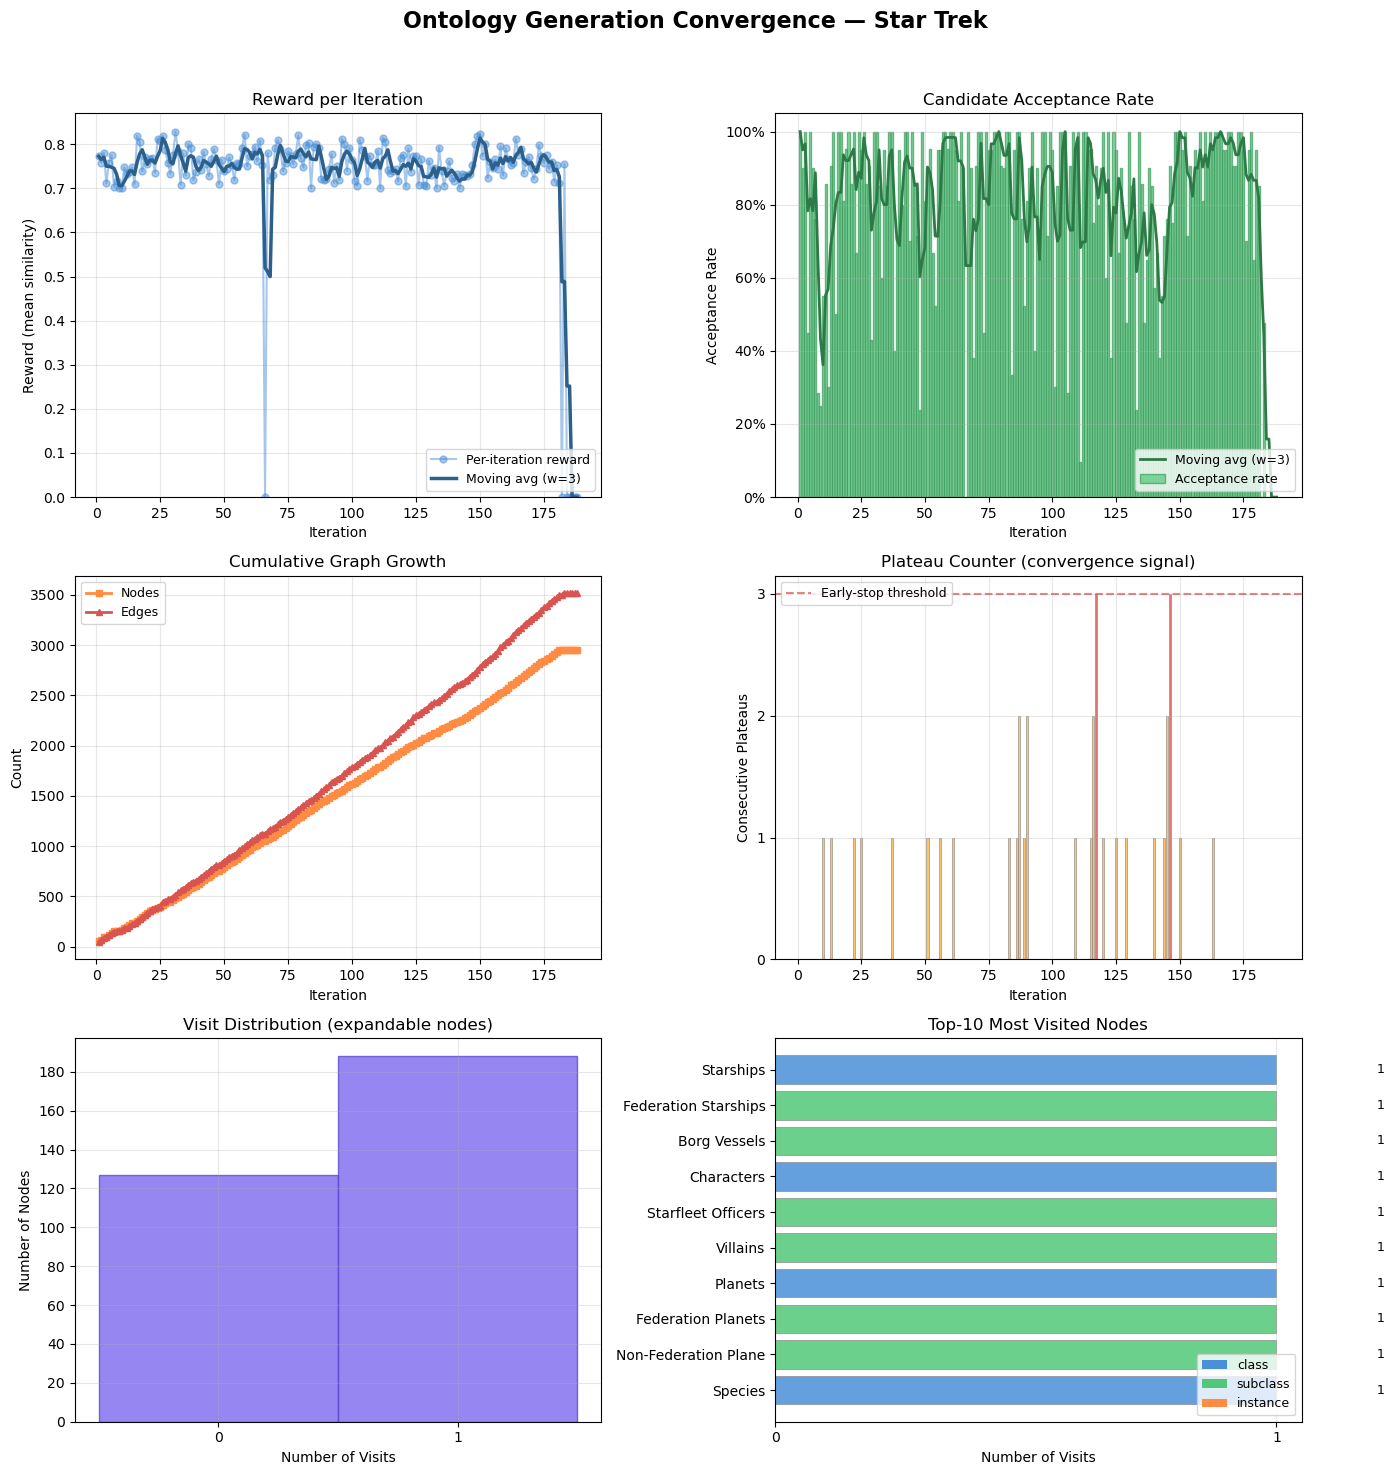


Pipeline complete!
Final graph: 2956 nodes, 3518 edges


In [4]:
# Run full generation pipeline (seed + validate + expand loop + serialize)
print(f"Running full pipeline with max_iterations={MAX_ITERATIONS}...")
print(f"Similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"Exploration constant (UCB1): {EXPLORATION_CONSTANT}\n")

ontology.generate_ontology()

# Post-run audit
print(ontology.history.summary())      # formatted summary
df = ontology.history.to_dataframe()   # pandas DataFrame
ontology.plot_convergence()            # matplotlib convergence charts

print(f"\nPipeline complete!")
print(f"Final graph: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")

In [5]:
# Display expansion statistics
print("\nExpansion Statistics:")
print(f"Total nodes in final ontology: {ontology.ontology_graph.number_of_nodes()}")
print(f"Total edges in final ontology: {ontology.ontology_graph.number_of_edges()}")

# Count nodes by level
print(f"\nNodes by level:")
for level in DEFAULT_LEVEL_SCHEMA:
    nodes_at_level = [n for n, d in ontology.ontology_graph.nodes(data=True) if d.get('level') == level.name]
    print(f"  {level.name}: {len(nodes_at_level)} nodes")

# Show UCB1 bandit statistics
print(f"\nUCB1 Bandit Statistics (node selection):")
if hasattr(ontology, 'bandit_stats') and ontology.bandit_stats:
    for node, stats in sorted(ontology.bandit_stats.items(), key=lambda x: x[1]['n_visits'], reverse=True)[:5]:
        visits = stats.get('n_visits', 0)
        reward = stats.get('total_reward', 0.0)
        mean_reward = reward / visits if visits > 0 else 0
        print(f"  {node}: {visits} visits, avg reward = {mean_reward:.2f}")
else:
    print("  (Bandit statistics not available)")


Expansion Statistics:
Total nodes in final ontology: 2956
Total edges in final ontology: 3518

Nodes by level:
  class: 34 nodes
  subclass: 281 nodes
  instance: 2641 nodes

UCB1 Bandit Statistics (node selection):
  (Bandit statistics not available)


## RDF Serialization

Convert the expanded ontology to RDF triples and serialize to standard formats (Turtle, XML, JSON-LD).

In [6]:
# Build RDF graph from the ontology
print("Building RDF graph from ontology...")
ontology.build_ontology()

if ontology.rdf is not None:
    num_triples = len(ontology.rdf)
    print(f"RDF graph built: {num_triples} triples")
else:
    print("ERROR: RDF graph construction failed.")

Building RDF graph from ontology...
RDF graph built: 6789 triples


In [7]:
# Serialize to Turtle format
print("Serializing ontology to Turtle format...")
turtle_output = ontology.serialize_ontology(format="turtle")

# Display first 50 lines of Turtle output
print("\nTurtle Output (first 50 lines):")
lines = turtle_output.split('\n')
for line in lines[:50]:
    print(line)

if len(lines) > 50:
    print(f"... ({len(lines) - 50} more lines)")

Serializing ontology to Turtle format...

Turtle Output (first 50 lines):
@prefix ex: <http://example.org/ontology/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

ex:Alien_Artifacts a ex:Ancient_Vulcan_Artifacts,
        ex:Iconian_Shields,
        ex:Klingon_Artifacts,
        ex:Orb_of_Wisdom,
        ex:The_Librarian_Planet,
        ex:The_Vault_of_the_Ancients,
        rdfs:Class ;
    rdfs:label "Alien Artifacts" .

ex:Alien_Encounters a rdfs:Class ;
    rdfs:label "Alien Encounters" ;
    rdfs:subClassOf ex:Episodes .

ex:Alien_Technology a rdfs:Class ;
    rdfs:label "Alien Technology" ;
    rdfs:subClassOf ex:Technologies .

ex:Ancient_Vulcan_Artifacts a rdfs:Class ;
    rdfs:label "Ancient Vulcan Artifacts" ;
    rdfs:subClassOf ex:Artifacts .

ex:Andoria a rdfs:Class ;
    rdfs:label "Andoria" ;
    rdfs:subClassOf ex:Planets .

ex:Andorian_Civil_War a rdfs:Class ;
    rdfs:label "Andorian Civil War" ;
    rdfs:subClassOf ex:Galactic_Events .

ex:Andorian_Diploma

In [8]:
# Save to file
output_path = "../output/ontology.ttl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w') as f:
    f.write(turtle_output)

print(f"Ontology saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

Ontology saved to: ../output/ontology.ttl
File size: 279546 bytes


## Visualization


In [9]:
# Interactive full-page HTML graph (pyvis)
print("Rendering interactive HTML graph...")
html_path = ontology.visualize_interactive(output_path="ontology_longrun.html")
print(f"Interactive graph saved to: {html_path}")
print("Open the HTML file in a browser for full-page pan-and-zoom exploration.")

Rendering interactive HTML graph...
ontology_longrun.html
Interactive graph saved to: /workspaces/thesis-llml-onthology/notebooks/ontology_longrun.html
Open the HTML file in a browser for full-page pan-and-zoom exploration.
